In [1]:
import numpy as np
import pandas as pd

# activity_labels / features / X_test / X_train / Y_test / Y_train 업로드

In [2]:
feature_name_df = pd.read_csv('features.txt', sep ='\s+', header = None, names = ['index', 'feature_name'], engine = 'python')

In [3]:
feature_name_df.head()

,index,feature_name
0,1,tBodyAcc-mean()-X
1,2,tBodyAcc-mean()-Y
2,3,tBodyAcc-mean()-Z
3,4,tBodyAcc-std()-X
4,5,tBodyAcc-std()-Y


In [4]:
feature_dup_df = feature_name_df.groupby('feature_name').count()
print(feature_dup_df[feature_dup_df['index'] > 1].count())
feature_dup_df[feature_dup_df['index'] > 1].head(10)

index    42
dtype: int64


,index
feature_name,
"fBodyAcc-bandsEnergy()-1,16",3
"fBodyAcc-bandsEnergy()-1,24",3
"fBodyAcc-bandsEnergy()-1,8",3
"fBodyAcc-bandsEnergy()-17,24",3
"fBodyAcc-bandsEnergy()-17,32",3
"fBodyAcc-bandsEnergy()-25,32",3
"fBodyAcc-bandsEnergy()-25,48",3
"fBodyAcc-bandsEnergy()-33,40",3
"fBodyAcc-bandsEnergy()-33,48",3


In [5]:
feature_dup_df = pd.DataFrame(data=feature_name_df.groupby('feature_name').cumcount(), columns=['dup_cnt'])

In [6]:
feature_dup_df = feature_dup_df.reset_index()

In [7]:
feature_dup_df.head()

,index,dup_cnt
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0


In [8]:
new_feature_name_df = pd.merge(feature_name_df.reset_index(), feature_dup_df, how='outer')

In [9]:
new_feature_name_df.head()

,level_0,index,feature_name,dup_cnt
0,0.0,1,tBodyAcc-mean()-X,0.0
1,1.0,2,tBodyAcc-mean()-Y,0.0
2,2.0,3,tBodyAcc-mean()-Z,0.0
3,3.0,4,tBodyAcc-std()-X,0.0
4,4.0,5,tBodyAcc-std()-Y,0.0


In [10]:
new_feature_name_df['feature_name'] = new_feature_name_df[['feature_name', 'dup_cnt']].apply(lambda x : x[0]+'_'+str(x[1]) if x[1] > 0 else x[0], axis=1)

In [11]:
new_feature_name_df.head()

,level_0,index,feature_name,dup_cnt
0,0.0,1,tBodyAcc-mean()-X,0.0
1,1.0,2,tBodyAcc-mean()-Y,0.0
2,2.0,3,tBodyAcc-mean()-Z,0.0
3,3.0,4,tBodyAcc-std()-X,0.0
4,4.0,5,tBodyAcc-std()-Y,0.0


In [12]:
new_feautre_name = new_feature_name_df.drop([561], axis=0, inplace=True)  # 561에 Nan이 존재한다네요

In [13]:
# 피처명을 컬럼으로 부여하기 위해 리스트 객체로 다시 변환
feature_name = new_feature_name_df.iloc[:, 2].values.tolist() # 교재랑 다름

In [14]:
feature_name[:5]

['tBodyAcc-mean()-X',
 'tBodyAcc-mean()-Y',
 'tBodyAcc-mean()-Z',
 'tBodyAcc-std()-X',
 'tBodyAcc-std()-Y']

In [41]:
X_train = pd.read_csv('X_train.txt', sep='\s+', names = feature_name, engine='python')
X_test = pd.read_csv('X_test.txt', sep='\s+', names = feature_name, engine='python')

Y_train = pd.read_csv('y_train.txt', sep='\s+', header = None, names = ['action'], engine='python')
Y_test = pd.read_csv('y_test.txt', sep='\s+', header = None, names = ['action'], engine='python')

In [42]:
X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

((7352, 561), (7352, 1), (2947, 561), (2947, 1))

In [43]:
print(Y_train['action'].value_counts())

6    1407
5    1374
4    1286
1    1226
2    1073
3     986
Name: action, dtype: int64


In [44]:
label_name_df = pd.read_csv('activity_labels.txt', sep='\s+', header = None, names = ['index', 'label'], engine='python')

In [45]:
label_name = label_name_df.iloc[:, 1].values.tolist()
label_name

['WALKING',
 'WALKING_UPSTAIRS',
 'WALKING_DOWNSTAIRS',
 'SITTING',
 'STANDING',
 'LAYING']

In [46]:
from sklearn.tree import DecisionTreeClassifier

In [47]:
dt_HAR = DecisionTreeClassifier(random_state = 156)

In [48]:
dt_HAR.fit(X_train, Y_train)

DecisionTreeClassifier(random_state=156)

In [49]:
Y_predict = dt_HAR.predict(X_test)

In [50]:
from sklearn.metrics import accuracy_score

In [52]:
accuracy = accuracy_score(Y_test, Y_predict)
print('결정 트리 예측 정확도: {0:.4f}'.format(accuracy))

결정 트리 예측 정확도: 0.8548


In [53]:
from sklearn.model_selection import GridSearchCV
params = {
    'max_depth' : [6, 8, 10, 12, 16, 20, 24]
}

In [56]:
grid_cv = GridSearchCV(dt_HAR, param_grid = params, scoring = 'accuracy', cv = 5, return_train_score = True)
grid_cv.fit(X_train, Y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=156),
             param_grid={'max_depth': [6, 8, 10, 12, 16, 20, 24]},
             return_train_score=True, scoring='accuracy')

In [59]:
cv_results_df = pd.DataFrame(grid_cv.cv_results_)

cv_results_df[['param_max_depth', 'mean_test_score', 'mean_train_score']]

,param_max_depth,mean_test_score,mean_train_score
0,6,0.850791,0.944879
1,8,0.851069,0.982692
2,10,0.851209,0.993403
3,12,0.844135,0.997212
4,16,0.851344,0.999660
5,20,0.850800,0.999966
6,24,0.849440,1.000000


In [60]:
print('최고 평균 정확도: {0:.4f}, 최적 하이퍼 매개변수: {1}'.format(grid_cv.best_score_, grid_cv.best_params_))

최고 평균 정확도: 0.8513, 최적 하이퍼 매개변수: {'max_depth': 16}


In [61]:
params = {
    'max_depth' : [8, 16, 20],
    'min_samples_split' : [8, 16, 24]
}

grid_cv = GridSearchCV(dt_HAR, param_grid = params, scoring = 'accuracy', cv = 5, return_train_score = True)
grid_cv.fit(X_train, Y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=156),
             param_grid={'max_depth': [8, 16, 20],
                         'min_samples_split': [8, 16, 24]},
             return_train_score=True, scoring='accuracy')

In [62]:
cv_results_df = pd.DataFrame(grid_cv.cv_results_)

cv_results_df[['param_max_depth', 'param_min_samples_split', 'mean_test_score', 'mean_train_score']]

,param_max_depth,param_min_samples_split,mean_test_score,mean_train_score
0,8,8,0.852023,0.981468
1,8,16,0.854879,0.979836
2,8,24,0.851342,0.978237
3,16,8,0.844136,0.994457
4,16,16,0.847127,0.990479
5,16,24,0.849439,0.986772
6,20,8,0.846040,0.994491
7,20,16,0.848624,0.990479
8,20,24,0.849167,0.986772


In [63]:
print('최고 평균 정확도: {0:.4f}, 최적 하이퍼 매개변수: {1}'.format(grid_cv.best_score_, grid_cv.best_params_))

최고 평균 정확도: 0.8549, 최적 하이퍼 매개변수: {'max_depth': 8, 'min_samples_split': 16}


In [65]:
best_dt_HAR = grid_cv.best_estimator_
best_Y_predict = best_dt_HAR.predict(X_test)
best_accuracy = accuracy_score(Y_test, best_Y_predict)

print('best 결정 트리 예측 정확도: {0:.4f}'.format(best_accuracy))

best 결정 트리 예측 정확도: 0.8717


In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

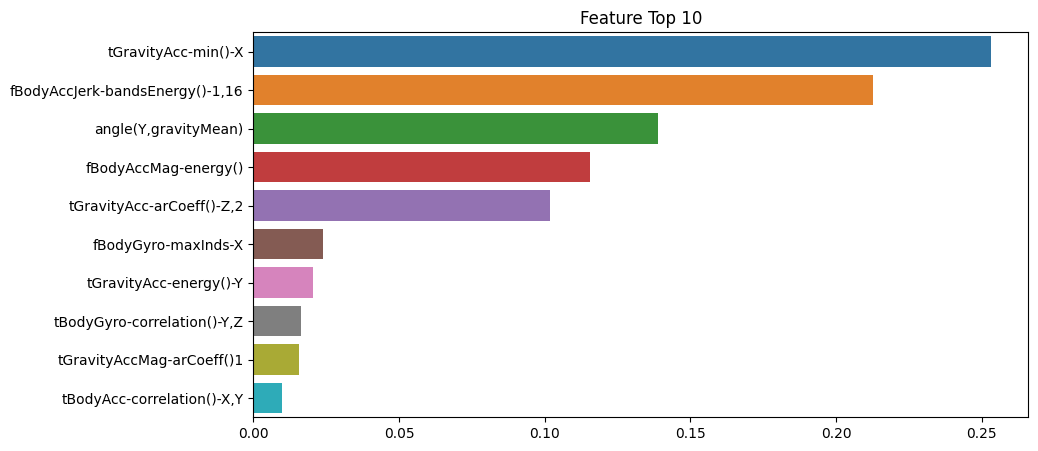

In [67]:
feature_importance_values = best_dt_HAR.feature_importances_
feature_importance_values_s = pd.Series(feature_importance_values, index = X_train.columns)
feature_top10 = feature_importance_values_s.sort_values(ascending = False)[:10]

plt.figure(figsize = (10, 5))
plt.title('Feature Top 10')
sns.barplot(x = feature_top10, y = feature_top10.index)
plt.show()

In [68]:
!pip install graphviz

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


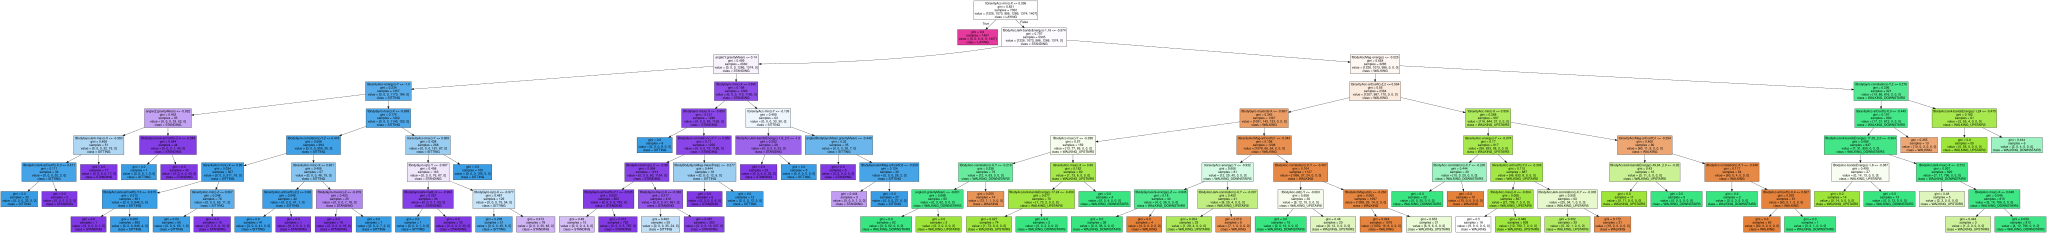

In [71]:
from sklearn.tree import export_graphviz

import graphviz

export_graphviz(best_dt_HAR, out_file = "tree.dot", class_names = label_name, feature_names = feature_name, impurity = True, filled = True)

#위에서 생성된 tree.dot 파일을 Graphviz가 읽어서 시각화
with open("tree.dot") as f:
    dot_graph = f.read()

graphviz.Source(dot_graph)

In [72]:
graphviz.Source(dot_graph).render('tree', format="png")

'tree.png'